### Netural network intuition

#### Perceptron, weight, bias

- Perceptron là một bộ phân loại tuyến tính đơn giản. Nó nhận các features, nhân với weights, cộng bias, rồi đưa qua hàm quyết định.
  $$
  z=w_1x_1+w_2x_2+\cdots+w_nx_n+b
  $$

Với Perceptron cổ điển dùng hàm Step:

$$
\hat y=
\begin{cases}
1 & z\geq0\\
0 & z<0
\end{cases}
$$

- Weight vs bias
  - Weight là quyết định cho mức độ ảnh hưởng của 1 feature
    - w>0: khi feature tăng thì sẽ làm cho z tăng, khi giữ các yếu tố khác cố định
    - w<0: khi feature giảm thì làm cho z giảm
    - w gần bằng 0: feature ít ảnh hưởng tới z
  - Bias: dịch chuyển ngưỡng quyết định. Không có bias, ranh giới \(w_1x_1+w_2x_2=0\) luôn đi qua gốc tọa độ.


#### Neurons layer

- tại sao ta lại cần neurons vì do 1 cái perceptron thì nó chỉ tuyến tính chỉ có 1 đường còn cái neuros thì nó là nhiều ái perceptron mà cái này thì cũng thẳng nên khi cần cong lại thì sau này có cái gọi là active funcion 
- Cấu trúc của 1 mạng neurons
  - input layer: đầu vào
  - hidden layer: học, cải tiến, biến đổi trung gian
  - output layern: kết quả
- Hidden layer đó là gì
  - Ví dụ trong phân loại email, một số neuron có thể học các tín hiệu liên quan đến:
    - Ngôn ngữ quảng cáo.
    - Ngôn ngữ công việc.
    - Cách kết hợp nhiều từ.
- cách tính tổng số hyperparammeter
  - ví dụ mạng 3 - 4 -1  
    - 3 input features.
    - 4 neurons trong hidden layer.
    - 1 neuron trong output layer.
  - => P = (3+1)* 4 + (4+1)*1 : trước +1 nhân giữa + (giữa +1)*cuối

#### Active Function
- Nếu neuron chỉ tính \(z=wx+b\) mà không có phép biến đổi phi tuyến, thì dù xếp nhiều lớp, toàn bộ mạng vẫn tương đương một phép biến đổi tuyến tính.
- Activation Function giúp mạng học những mối quan hệ phức tạp hơn.
- có 4 loại hàm
  - Sigmoid: 0->1
  - Relu: ReLU(z) = Max(0,z)
    - Số âm thành 0; số dương giữ nguyên. Rất phổ biến trong hidden layers.
  - Tanh(z) đưa về giá trị khoản -1, 1
  - softmax: Chuyển nhiều scores thành các xác suất có tổng bằng 1. Thường dùng cho multiclass classification.- cái này nó chỉ là nằm trước với cái đầu ra khôgn làm cong cái boudary mà nó chỉ là 1 thằng chuẩn hóa xme các phân vùng chiếm bao nhiều % thôi
  - Arg max: chọn class có cái xác xuất cao nhất 
- 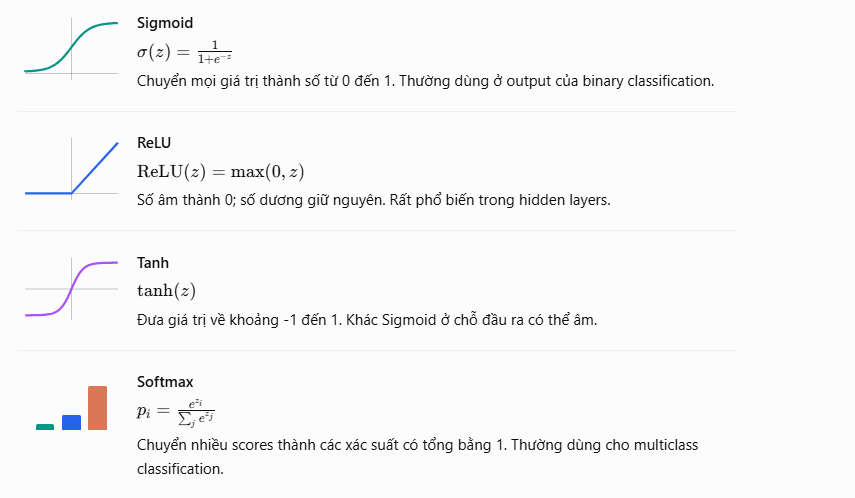  
- 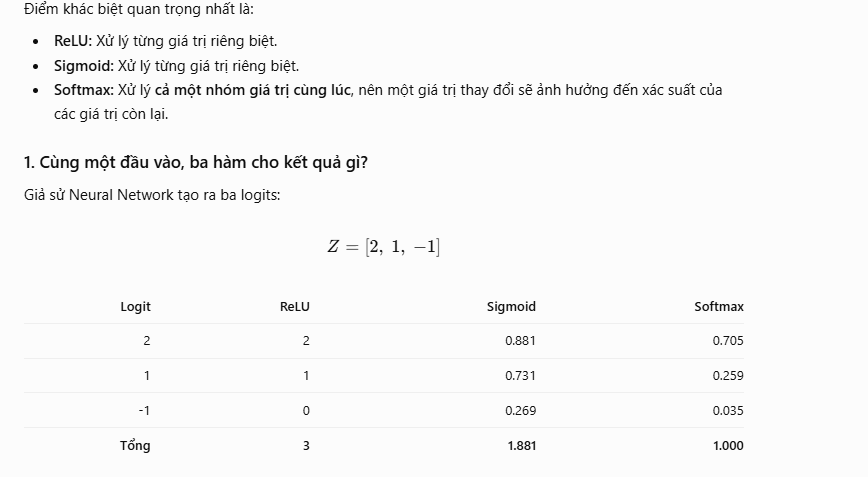

#### Forward Propagation
- Forward Propagation là quá trình tính toán từ input đến output.
-  Lan truyền tiến) là quá trình dữ liệu đầu vào (input) di chuyển qua các lớp (layers) của mạng nơ-ron từ trái sang phải (từ lớp đầu vào qua các lớp ẩn đến lớp đầu ra) để tính toán ra kết quả dự đoán cuối cùng.
-  

#### Loss Function: hàm sai số
Với bài toán hai class:
$$
L=-[y\ln(\hat y)+(1-y)\ln(1-\hat y)]
$$  
y mủ là dự đoán, y là thực tế

MSE cho Regression
Với bài toán dự đoán số như giá nhà, sách cũng sử dụng Mean Squared Error:
$$
MSE=\frac1n\sum_{i=1}^{n}(y_i-\hat y_i)^2
$$

#### Backpropagation — Mạng biết mình sai ở đâu như thế nào?
6.2. Backpropagation làm gì?
Backpropagation sử dụng Chain Rule (quy tắc đạo hàm hàm hợp) để tính gradient của Loss đối với từng parameter.
Ví dụ:
$$
\frac{\partial L}{\partial w}
$$


$$\\{\frac{\partial L}{\partial w}=2(\hat y-y)x}
$$

Đọc là: Loss thay đổi như thế nào khi weight thay đổi một lượng rất nhỏ?
- Gradient dương: tăng weight một chút có xu hướng làm Loss tăng.
- Gradient âm: tăng weight một chút có xu hướng làm Loss giảm.
- Gradient gần 0: Loss ít thay đổi khi weight thay đổi nhỏ, tại vị trí hiện tại.  
  
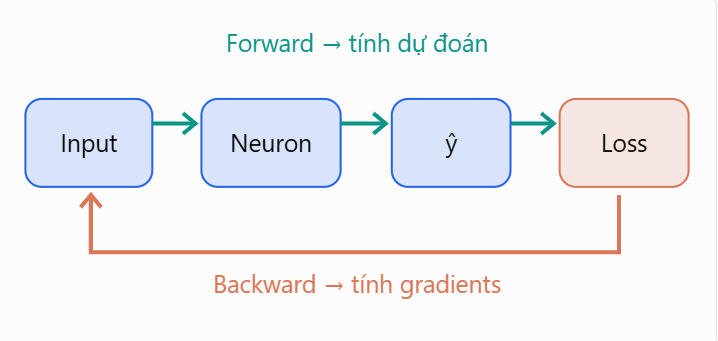  
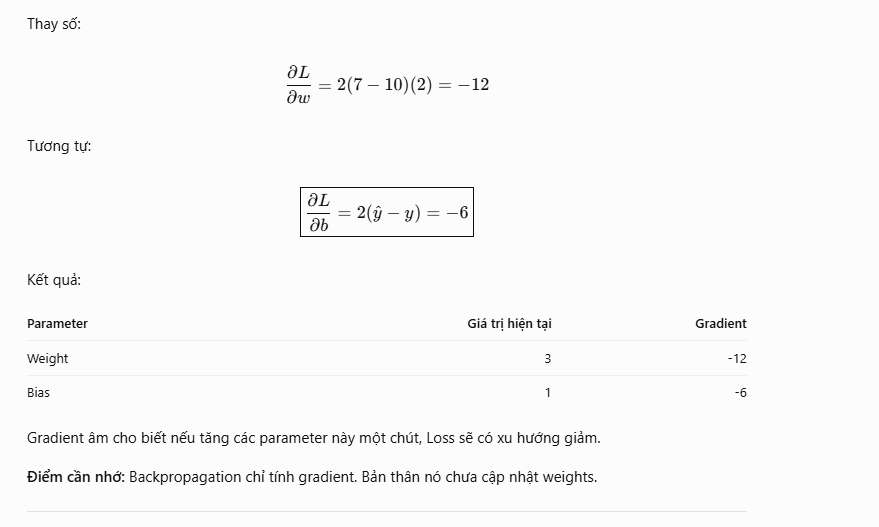

#### Gradient Descent và Learning Rate
Sau khi Backpropagation tính được gradient, Gradient Descent sử dụng gradient để cập nhật parameters.
Công thức:
$$\boxed{w_{\text{new}}=w_{\text{old}}-\eta\frac{\partial L}{\partial w}}
[$$


Trong đó:
- \(w\): Weight.
- \(\eta\) (eta): Learning Rate.
- \(\frac{\partial L}{\partial w}\): Gradient.
Bias cũng được cập nhật theo công thức tương tự.  
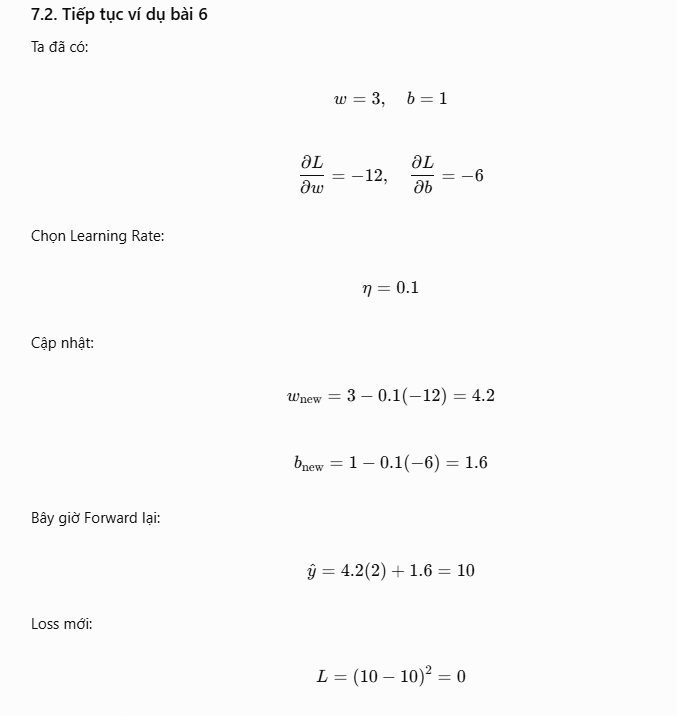  


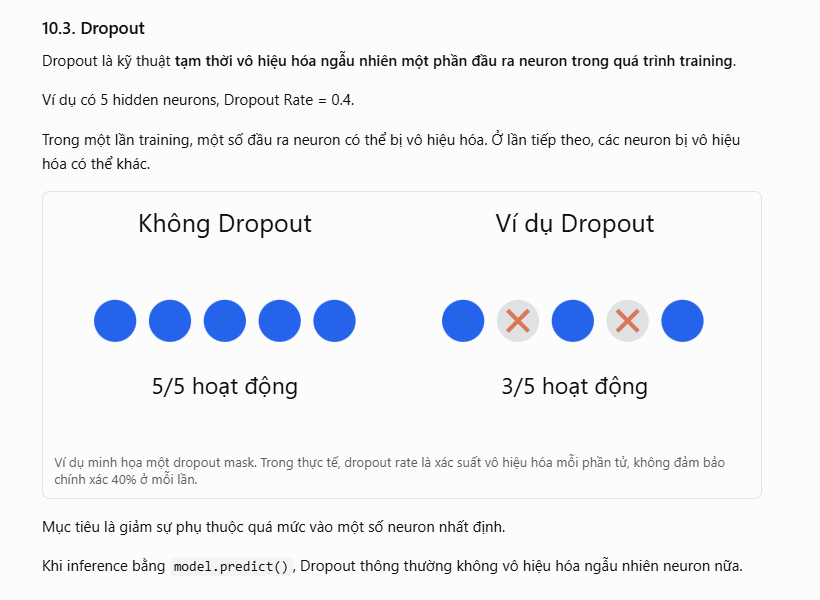  
<pre>
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Input(shape=(20,)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])</pre>

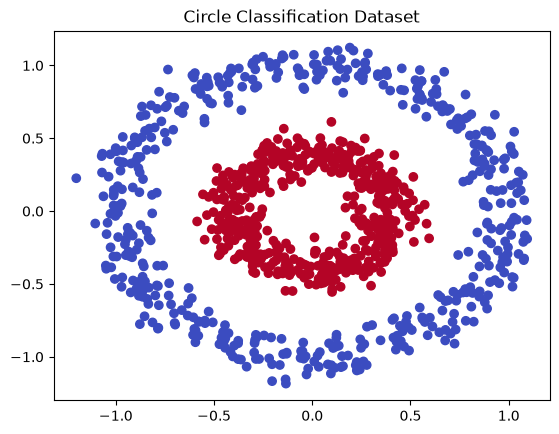

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Tạo dữ liệu phi tuyến
X, y = make_circles(
    n_samples=1000,
    factor=0.4,
    noise=0.08,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")
plt.title("Circle Classification Dataset")
plt.show()

In [6]:
model = Sequential([
    Input(shape=(2,)),

    Dense(16, activation="relu"),
    Dense(8, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [8]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))

Test Loss: 0.003501330269500613
Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



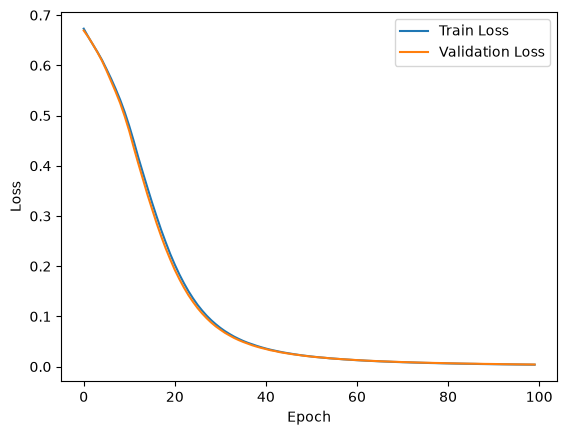

In [9]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Example code with karas 



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Setting random seeds to get reproducible results
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(1)

In [3]:
# Some functions to plot our points and draw the lines
def plot_points(features, labels, point_size=25):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = point_size,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = point_size,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.legend(['label 1','label 0'])

def draw_line(a,b,c, color='black', linewidth=2.0, linestyle='solid', starting=0, ending=3):
    # Plotting the line ax + by + c = 0
    x = np.linspace(starting, ending, 1000)
    plt.plot(x, -c/b - a*x/b, linestyle=linestyle, color=color, linewidth=linewidth)

f = lambda x: int(x[1]>x[0])
def g(Z):
    return np.array([f(i) for i in Z])

def plot_model(X, y, model):
    X = np.array(X)
    y = np.array(y)
    plot_step = 0.2
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = g(Z).reshape(xx.shape)
    plt.contour(xx, yy, Z, colors = 'k',linewidths = 1)
    plot_points(X, y)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.show()

In [4]:
# IMPORTANT: ONLY RUN THIS CELL IF YOU HAVE CLONED THE REPO
df = pd.read_csv('one_circle.csv', index_col=0)

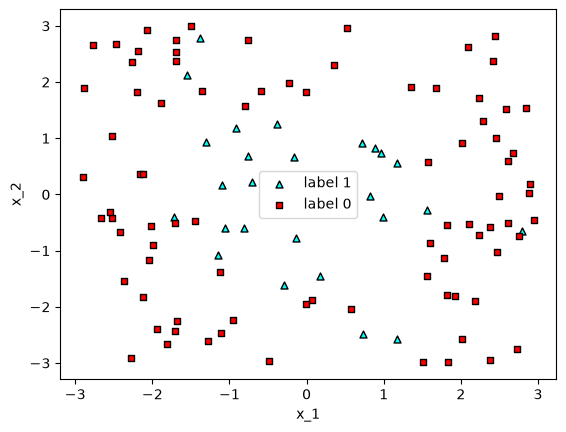

In [5]:
x = np.array(df[['x_1', 'x_2']])
y = np.array(df['y']).astype(int)
plot_points(x,y)

In [5]:
df

,x_1,x_2,y
0,-0.759416,2.753240,0
1,-1.885278,1.629527,0
2,2.463302,-1.023869,0
3,-1.986004,-0.898810,0
4,2.010834,-2.580117,0
...,...,...,...
105,-1.376637,2.778703,1
106,-0.703722,0.215382,1
107,0.729767,-2.479655,1
108,-1.715920,-0.393404,1


In [6]:
x[:10]

array([[-0.759416  ,  2.7532401 ],
       [-1.8852779 ,  1.62952654],
       [ 2.46330243, -1.02386888],
       [-1.98600415, -0.89880979],
       [ 2.01083403, -2.58011745],
       [ 2.41018752,  2.37050087],
       [ 1.59914005, -0.86273162],
       [-1.10985644, -2.46969746],
       [ 2.4473419 ,  2.81117994],
       [-1.69773161,  2.53984757]])

In [7]:
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [8]:
# Categorizing the output 
# One-hot encoding the output variable

from tensorflow.keras.utils import to_categorical
categorized_y = np.array(to_categorical(y, 2))
categorized_y

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.

### Building and compiling the neural network

In [9]:
# Imports
#import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
#from tensorflow.keras.layers import Dense, Dropout, Activation
#from tensorflow.keras.optimizers import SGD

# Building the model
# Drop out bỏ đi 1 số cái tránh ơverfit
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(2,)))
model.add(Dropout(.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(.2))
model.add(Dense(2, activation='softmax'))

# Compiling the model
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

d:\TrainAI\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,770 (34.26 KB)

 Trainable params: 8,770 (34.26 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.fit(x, categorized_y, epochs=100, batch_size=10)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7455 - loss: 0.5383  
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4697 
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4641 
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4528 
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7636 - loss: 0.4518 
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4461 
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4464 
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4177 
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4285 
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4095 
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4102 
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


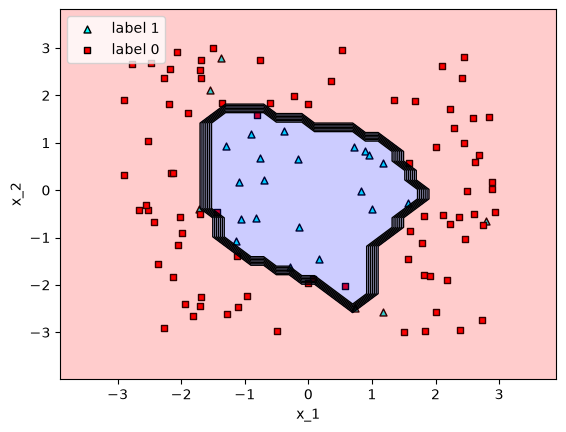

In [13]:
plot_model(x, y, model)

### Model 2

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model2 = Sequential([
    Input(shape=(2,)),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(64, activation="tanh"),
    Dropout(0.2),

    Dense(2, activation="softmax")
])

model2.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,770 (34.26 KB)

 Trainable params: 8,770 (34.26 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model2.fit(x, categorized_y, epochs=100, batch_size=10)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6727 - loss: 0.5756  
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7636 - loss: 0.4617 
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4612 
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4526 
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4542 
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4402 
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4261 
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4094 
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4288 
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7636 - loss: 0.4266 
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7727 - loss: 0.4005 
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step


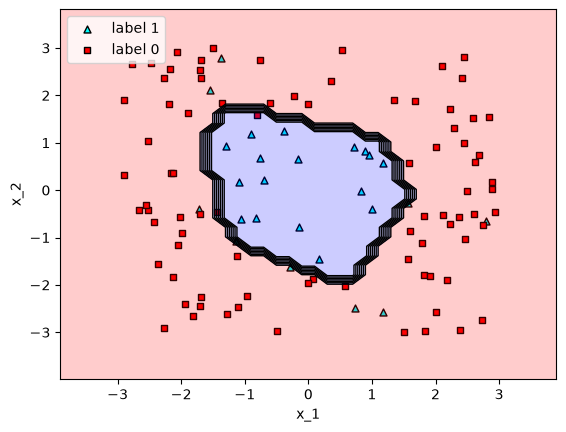

In [29]:
plot_model(x, y, model2)